In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import process_data as pd

In [2]:
QKE = pd.make_data_dictionary("../results/62-fix_mat_small.csv", "../results/51-full_QKE-eps.csv")
QKE.keys()

dict_keys(['time', 'N_bins', 'rho', 'rhobar', 'f', 'Tcm', 'eps', 'w', 'dnde'])

In [3]:
P0, Px, Py, Pz = pd.make_P(QKE['rho'])

In [4]:
V_QKE = pd.V_mat(QKE)

In [5]:
t = QKE['time']
Vy = V_QKE[1,:]
dy = np.diff(Vy)

In [6]:
#Finding indices for zero, min, zero, max points (QKE)

tlist = []
Vylist = []

for i in range(len(Vy)-2):
    
    if Vy[i]*Vy[i+1] <= 0:
        tlist.append(i)
        Vylist.append(i)
    if dy[i]*dy[i+1] < 0:
        tlist.append(i)
        Vylist.append(i)

t_index = np.array(tlist)
Vy_index = np.array(Vylist)

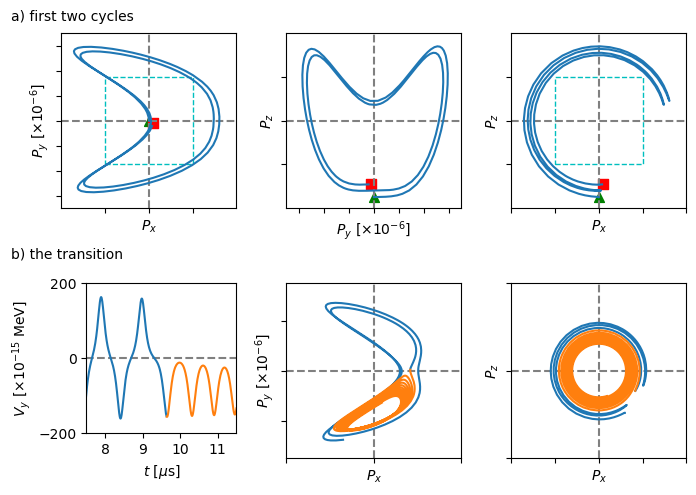

In [7]:
fig = plt.figure(figsize=(7,5))
subfigs = fig.subfigures(nrows=2, ncols=1, hspace=0)

xy1 = subfigs[0].add_axes([2/28, 1/10, 7/28, 7/10])
yz1 = subfigs[0].add_axes([11/28, 1/10, 7/28, 7/10])
xz1 = subfigs[0].add_axes([20/28, 1/10, 7/28, 7/10])

xy2 = subfigs[1].add_axes([11/28, 1/10, 7/28, 7/10])
xz2 = subfigs[1].add_axes([20/28, 1/10, 7/28, 7/10])

xy2.set_box_aspect(1)
xz2.set_box_aspect(1)

V2 = subfigs[1].add_axes([3/28, 2/10, 6/28, 6/10])

V2.axhline(0, c='0.50', ls='--')

bloch = [xy1, yz1, xz1, xy2, xz2]

for ax in bloch:
    ax.axhline(0, c='0.50', ls='--')
    ax.axvline(0, c='0.50', ls='--')

label_fontsize = 10

#xy1.scatter(Px[t_index,15][1:9], Py[t_index,15][1:9]*1e6)
xy1.scatter(Px[t_index,15][0],Py[t_index,15][0]*1e6, marker='^', color='green', s=50, label=r"$t_0$")
xy1.scatter(Px[t_index,15][8],Py[t_index,15][8]*1e6, marker='s', color='red', s=50, label=r"$t_f$")
xy1.plot(Px[t_index[0] : t_index[8],15], Py[t_index[0] : t_index[8],15]*1e6)
xy1.set_xlabel(r"$P_x$", fontsize=label_fontsize)
xy1.set_ylabel(r"$P_y~[\times 10^{-6}]$", fontsize=label_fontsize)
xy1.set_xticks([-0.2, 0, 0.2])
xy1.set_yticks([-0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6])
xy1.tick_params(labelbottom=False, labelleft=False)
xy1.set_xlim(-0.4,0.4)
xy1.set_ylim(-0.7,0.7)
xy1.add_patch(plt.Rectangle((-.2, -.35), .4, .7, ls="--", fc="none", ec="c"))

#yz1.scatter(Py[t_index,15][1:9]*1e6, Pz[t_index,15][1:9])
yz1.scatter(Py[t_index,15][0]*1e6,Pz[t_index,15][0], marker='^', color='green', s=50, label=r"$t_0$")
yz1.scatter(Py[t_index,15][8]*1e6,Pz[t_index,15][8], marker='s', color='red', s=50, label=r"$t_f$")
yz1.plot(Py[t_index[0] : t_index[8],15]*1e6, Pz[t_index[0] : t_index[8],15])
yz1.set_xlabel(r"$P_y~[\times 10^{-6}]$", fontsize=label_fontsize)
yz1.set_ylabel(r"$P_z$", fontsize=label_fontsize)
yz1.set_yticks([-0.2, 0, 0.2])
yz1.set_xticks([-0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6])
yz1.tick_params(labelbottom=False, labelleft=False) 
yz1.set_xlim(-0.7,0.7)
yz1.set_ylim(-0.4,0.4)

#xz1.scatter(Pz[t_index,15][1:9],Px[t_index,15][1:9])
xz1.scatter(Px[t_index,15][0],Pz[t_index,15][0], marker='^', color='green', s=50, label=r"$t_0$")
xz1.scatter(Px[t_index,15][8],Pz[t_index,15][8], marker='s', color='red', s=50, label=r"$t_f$")
xz1.plot(Px[t_index[0] : t_index[8],15], Pz[t_index[0] : t_index[8],15])
xz1.set_ylabel(r"$P_z$", fontsize=label_fontsize)
xz1.set_xlabel(r"$P_x$", fontsize=label_fontsize)
xz1.set_yticks([-0.2, 0, 0.2])
xz1.set_yticks([-0.2, 0, 0.2])
xz1.tick_params(labelbottom=False, labelleft=False) 
xz1.set_xlim(-0.4,0.4)
xz1.set_ylim(-0.4,0.4)
xz1.add_patch(plt.Rectangle((-.2, -.2), .4, .4, ls="--", fc="none", ec="c"))


xy2.plot(Px[t_index[43]:t_index[50],15], Py[t_index[43]:t_index[50],15]*1e6)
xy2.plot(Px[t_index[50]:,15], Py[t_index[50]:,15]*1e6)
xy2.set_xticks([-0.2, 0, 0.2])
xy2.set_yticks([-0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6])
xy2.tick_params(labelbottom=False, labelleft=False) 
xy2.set_xlabel(r"$P_x$", fontsize=label_fontsize)
xy2.set_ylabel(r"$P_y~[\times 10^{-6}]$", fontsize=label_fontsize)
xy2.set_xlim(-0.2,0.2)
xy2.set_ylim(-0.35,0.35)

xz2.plot(Px[t_index[44]:t_index[50],15], Pz[t_index[44]:t_index[50],15])
xz2.plot(Px[t_index[50]:,15], Pz[t_index[50]:,15])
xz2.set_ylabel(r"$P_z$", fontsize=label_fontsize)
xz2.set_xlabel(r"$P_x$", fontsize=label_fontsize)
xz2.set_yticks([-0.2, 0, 0.2])
xz2.set_yticks([-0.2, 0, 0.2])
xz2.tick_params(labelbottom=False, labelleft=False) 
xz2.set_xlim(-0.2,0.2)
xz2.set_ylim(-0.2,0.2)

V2.plot(t[t_index[43]:t_index[51]], Vy[Vy_index[43]:Vy_index[51]]*1e15)
V2.plot(t[t_index[51] :], Vy[Vy_index[51] :]*1e15)
V2.set_xlim(7.5,11.5)
V2.set_xticks([8,9,10,11])
V2.set_xticklabels([8,9,10,11])
V2.set_yticks([-200, 0, 200])
V2.set_xlabel(r"$t~[\mu{\rm s}]$", fontsize=label_fontsize)
V2.set_ylabel(r"$V_y~[\times 10^{-15}~\text{MeV}]$", fontsize=label_fontsize)

subfigs[0].text(0,0.85,"a) first two cycles", fontsize=label_fontsize)
subfigs[1].text(0,0.9,"b) the transition", fontsize=label_fontsize)

plt.savefig("Bloch.pdf", bbox_inches='tight')

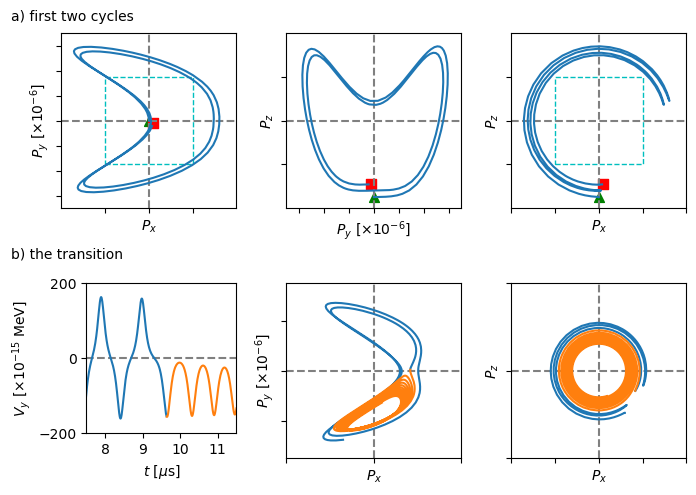

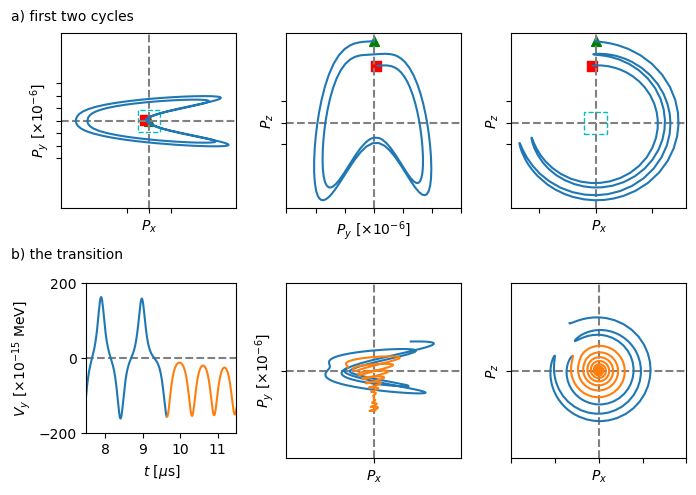

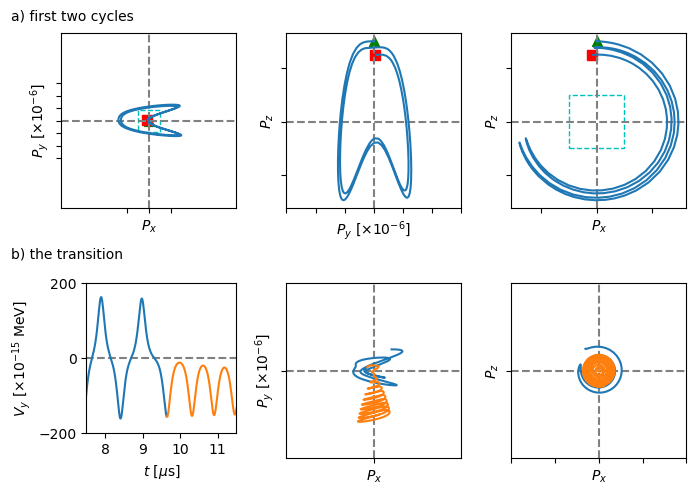

In [8]:
fig = plt.figure(figsize=(7,5))
subfigs = fig.subfigures(nrows=2, ncols=1, hspace=0)

xy1 = subfigs[0].add_axes([2/28, 1/10, 7/28, 7/10])
yz1 = subfigs[0].add_axes([11/28, 1/10, 7/28, 7/10])
xz1 = subfigs[0].add_axes([20/28, 1/10, 7/28, 7/10])

xy2 = subfigs[1].add_axes([11/28, 1/10, 7/28, 7/10])
xz2 = subfigs[1].add_axes([20/28, 1/10, 7/28, 7/10])

xy2.set_box_aspect(1)
xz2.set_box_aspect(1)

V2 = subfigs[1].add_axes([3/28, 2/10, 6/28, 6/10])

V2.axhline(0, c='0.50', ls='--')

bloch = [xy1, yz1, xz1, xy2, xz2]

for ax in bloch:
    ax.axhline(0, c='0.50', ls='--')
    ax.axvline(0, c='0.50', ls='--')

label_fontsize = 10

#xy1.scatter(Px[t_index,15][1:9], Py[t_index,15][1:9]*1e6)
xy1.scatter(Px[t_index,15][0],Py[t_index,15][0]*1e6, marker='^', color='green', s=50, label=r"$t_0$")
xy1.scatter(Px[t_index,15][8],Py[t_index,15][8]*1e6, marker='s', color='red', s=50, label=r"$t_f$")
xy1.plot(Px[t_index[0] : t_index[8],15], Py[t_index[0] : t_index[8],15]*1e6)
xy1.set_xlabel(r"$P_x$", fontsize=label_fontsize)
xy1.set_ylabel(r"$P_y~[\times 10^{-6}]$", fontsize=label_fontsize)
xy1.set_xticks([-0.2, 0, 0.2])
xy1.set_yticks([-0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6])
xy1.tick_params(labelbottom=False, labelleft=False)
xy1.set_xlim(-0.4,0.4)
xy1.set_ylim(-0.7,0.7)
xy1.add_patch(plt.Rectangle((-.2, -.35), .4, .7, ls="--", fc="none", ec="c"))

#yz1.scatter(Py[t_index,15][1:9]*1e6, Pz[t_index,15][1:9])
yz1.scatter(Py[t_index,15][0]*1e6,Pz[t_index,15][0], marker='^', color='green', s=50, label=r"$t_0$")
yz1.scatter(Py[t_index,15][8]*1e6,Pz[t_index,15][8], marker='s', color='red', s=50, label=r"$t_f$")
yz1.plot(Py[t_index[0] : t_index[8],15]*1e6, Pz[t_index[0] : t_index[8],15])
yz1.set_xlabel(r"$P_y~[\times 10^{-6}]$", fontsize=label_fontsize)
yz1.set_ylabel(r"$P_z$", fontsize=label_fontsize)
yz1.set_yticks([-0.2, 0, 0.2])
yz1.set_xticks([-0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6])
yz1.tick_params(labelbottom=False, labelleft=False) 
yz1.set_xlim(-0.7,0.7)
yz1.set_ylim(-0.4,0.4)

#xz1.scatter(Pz[t_index,15][1:9],Px[t_index,15][1:9])
xz1.scatter(Px[t_index,15][0],Pz[t_index,15][0], marker='^', color='green', s=50, label=r"$t_0$")
xz1.scatter(Px[t_index,15][8],Pz[t_index,15][8], marker='s', color='red', s=50, label=r"$t_f$")
xz1.plot(Px[t_index[0] : t_index[8],15], Pz[t_index[0] : t_index[8],15])
xz1.set_ylabel(r"$P_z$", fontsize=label_fontsize)
xz1.set_xlabel(r"$P_x$", fontsize=label_fontsize)
xz1.set_yticks([-0.2, 0, 0.2])
xz1.set_yticks([-0.2, 0, 0.2])
xz1.tick_params(labelbottom=False, labelleft=False) 
xz1.set_xlim(-0.4,0.4)
xz1.set_ylim(-0.4,0.4)
xz1.add_patch(plt.Rectangle((-.2, -.2), .4, .4, ls="--", fc="none", ec="c"))


xy2.plot(Px[t_index[43]:t_index[50],15], Py[t_index[43]:t_index[50],15]*1e6)
xy2.plot(Px[t_index[50]:,15], Py[t_index[50]:,15]*1e6)
xy2.set_xticks([-0.2, 0, 0.2])
xy2.set_yticks([-0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6])
xy2.tick_params(labelbottom=False, labelleft=False) 
xy2.set_xlabel(r"$P_x$", fontsize=label_fontsize)
xy2.set_ylabel(r"$P_y~[\times 10^{-6}]$", fontsize=label_fontsize)
xy2.set_xlim(-0.2,0.2)
xy2.set_ylim(-0.35,0.35)

xz2.plot(Px[t_index[44]:t_index[50],15], Pz[t_index[44]:t_index[50],15])
xz2.plot(Px[t_index[50]:,15], Pz[t_index[50]:,15])
xz2.set_ylabel(r"$P_z$", fontsize=label_fontsize)
xz2.set_xlabel(r"$P_x$", fontsize=label_fontsize)
xz2.set_yticks([-0.2, 0, 0.2])
xz2.set_yticks([-0.2, 0, 0.2])
xz2.tick_params(labelbottom=False, labelleft=False) 
xz2.set_xlim(-0.2,0.2)
xz2.set_ylim(-0.2,0.2)

V2.plot(t[t_index[43]:t_index[51]], Vy[Vy_index[43]:Vy_index[51]]*1e15)
V2.plot(t[t_index[51] :], Vy[Vy_index[51] :]*1e15)
V2.set_xlim(7.5,11.5)
V2.set_xticks([8,9,10,11])
V2.set_xticklabels([8,9,10,11])
V2.set_yticks([-200, 0, 200])
V2.set_xlabel(r"$t~[\mu{\rm s}]$", fontsize=label_fontsize)
V2.set_ylabel(r"$V_y~[\times 10^{-15}~\text{MeV}]$", fontsize=label_fontsize)

subfigs[0].text(0,0.85,"a) first two cycles", fontsize=label_fontsize)
subfigs[1].text(0,0.9,"b) the transition", fontsize=label_fontsize)

plt.savefig("Bloch.pdf", bbox_inches='tight')









eps_index=45

fig = plt.figure(figsize=(7,5))
subfigs = fig.subfigures(nrows=2, ncols=1, hspace=0)

xy1 = subfigs[0].add_axes([2/28, 1/10, 7/28, 7/10])
yz1 = subfigs[0].add_axes([11/28, 1/10, 7/28, 7/10])
xz1 = subfigs[0].add_axes([20/28, 1/10, 7/28, 7/10])

xy2 = subfigs[1].add_axes([11/28, 1/10, 7/28, 7/10])
xz2 = subfigs[1].add_axes([20/28, 1/10, 7/28, 7/10])

xy2.set_box_aspect(1)
xz2.set_box_aspect(1)

V2 = subfigs[1].add_axes([3/28, 2/10, 6/28, 6/10])

V2.axhline(0, c='0.50', ls='--')

bloch = [xy1, yz1, xz1, xy2, xz2]

for ax in bloch:
    ax.axhline(0, c='0.50', ls='--')
    ax.axvline(0, c='0.50', ls='--')

label_fontsize = 10

#xy1.scatter(Px[t_index,15][1:9], Py[t_index,15][1:9]*1e6)
xy1.scatter(Px[t_index,eps_index][0],Py[t_index,eps_index][0]*1e6, marker='^', color='green', s=50, label=r"$t_0$")
xy1.scatter(Px[t_index,eps_index][8],Py[t_index,eps_index][8]*1e6, marker='s', color='red', s=50, label=r"$t_f$")
xy1.plot(Px[t_index[0] : t_index[8],eps_index], Py[t_index[0] : t_index[8],eps_index]*1e6)
xy1.set_xlabel(r"$P_x$", fontsize=label_fontsize)
xy1.set_ylabel(r"$P_y~[\times 10^{-6}]$", fontsize=label_fontsize)
xy1.set_xticks([-0.2, 0, 0.2])
xy1.set_yticks([-0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6])
xy1.tick_params(labelbottom=False, labelleft=False)
xy1.set_xlim(-0.8,0.8)
xy1.set_ylim(-1.4,1.4)
xy1.add_patch(plt.Rectangle((-.1, -.175), .2, .35, ls="--", fc="none", ec="c"))

#yz1.scatter(Py[t_index,15][1:9]*1e6, Pz[t_index,15][1:9])
yz1.scatter(Py[t_index,eps_index][0]*1e6,Pz[t_index,eps_index][0], marker='^', color='green', s=50, label=r"$t_0$")
yz1.scatter(Py[t_index,eps_index][8]*1e6,Pz[t_index,eps_index][8], marker='s', color='red', s=50, label=r"$t_f$")
yz1.plot(Py[t_index[0] : t_index[8],eps_index]*1e6, Pz[t_index[0] : t_index[8],eps_index])
yz1.set_xlabel(r"$P_y~[\times 10^{-6}]$", fontsize=label_fontsize)
yz1.set_ylabel(r"$P_z$", fontsize=label_fontsize)
yz1.set_yticks([-0.2, 0, 0.2])
yz1.set_xticks([-0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6])
yz1.tick_params(labelbottom=False, labelleft=False) 
#yz1.set_xlim(-0.7,0.7)
#yz1.set_ylim(-0.4,0.4)

#xz1.scatter(Pz[t_index,15][1:9],Px[t_index,15][1:9])
xz1.scatter(Px[t_index,eps_index][0],Pz[t_index,eps_index][0], marker='^', color='green', s=50, label=r"$t_0$")
xz1.scatter(Px[t_index,eps_index][8],Pz[t_index,eps_index][8], marker='s', color='red', s=50, label=r"$t_f$")
xz1.plot(Px[t_index[0] : t_index[8],eps_index], Pz[t_index[0] : t_index[8],eps_index])
xz1.set_ylabel(r"$P_z$", fontsize=label_fontsize)
xz1.set_xlabel(r"$P_x$", fontsize=label_fontsize)
xz1.set_yticks([-0.2, 0, 0.2])
xz1.set_yticks([-0.2, 0, 0.2])
xz1.tick_params(labelbottom=False, labelleft=False) 
#xz1.set_xlim(-0.4,0.4)
#xz1.set_ylim(-0.4,0.4)
xz1.add_patch(plt.Rectangle((-.1, -.1), .2, .2, ls="--", fc="none", ec="c"))


xy2.plot(Px[t_index[43]:t_index[50],eps_index], Py[t_index[43]:t_index[50],eps_index]*1e6)
xy2.plot(Px[t_index[50]:,eps_index], Py[t_index[50]:,eps_index]*1e6)
xy2.set_xticks([-0.2, 0, 0.2])
xy2.set_yticks([-0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6])
xy2.tick_params(labelbottom=False, labelleft=False) 
xy2.set_xlabel(r"$P_x$", fontsize=label_fontsize)
xy2.set_ylabel(r"$P_y~[\times 10^{-6}]$", fontsize=label_fontsize)
xy2.set_xlim(-0.1,0.1)
xy2.set_ylim(-0.175,0.175)

xz2.plot(Px[t_index[44]:t_index[50],eps_index], Pz[t_index[44]:t_index[50],eps_index])
xz2.plot(Px[t_index[50]:,eps_index], Pz[t_index[50]:,eps_index])
xz2.set_ylabel(r"$P_z$", fontsize=label_fontsize)
xz2.set_xlabel(r"$P_x$", fontsize=label_fontsize)
xz2.set_yticks([-0.2, 0, 0.2])
xz2.set_yticks([-0.2, 0, 0.2])
xz2.tick_params(labelbottom=False, labelleft=False) 
xz2.set_xlim(-0.1,0.1)
xz2.set_ylim(-0.1,0.1)

V2.plot(t[t_index[43]:t_index[51]], Vy[Vy_index[43]:Vy_index[51]]*1e15)
V2.plot(t[t_index[51] :], Vy[Vy_index[51] :]*1e15)
V2.set_xlim(7.5,11.5)
V2.set_xticks([8,9,10,11])
V2.set_xticklabels([8,9,10,11])
V2.set_yticks([-200, 0, 200])
V2.set_xlabel(r"$t~[\mu{\rm s}]$", fontsize=label_fontsize)
V2.set_ylabel(r"$V_y~[\times 10^{-15}~\text{MeV}]$", fontsize=label_fontsize)

subfigs[0].text(0,0.85,"a) first two cycles", fontsize=label_fontsize)
subfigs[1].text(0,0.9,"b) the transition", fontsize=label_fontsize)

plt.savefig("Bloch.pdf", bbox_inches='tight')











eps_index=30

fig = plt.figure(figsize=(7,5))
subfigs = fig.subfigures(nrows=2, ncols=1, hspace=0)

xy1 = subfigs[0].add_axes([2/28, 1/10, 7/28, 7/10])
yz1 = subfigs[0].add_axes([11/28, 1/10, 7/28, 7/10])
xz1 = subfigs[0].add_axes([20/28, 1/10, 7/28, 7/10])

xy2 = subfigs[1].add_axes([11/28, 1/10, 7/28, 7/10])
xz2 = subfigs[1].add_axes([20/28, 1/10, 7/28, 7/10])

xy2.set_box_aspect(1)
xz2.set_box_aspect(1)

V2 = subfigs[1].add_axes([3/28, 2/10, 6/28, 6/10])

V2.axhline(0, c='0.50', ls='--')

bloch = [xy1, yz1, xz1, xy2, xz2]

for ax in bloch:
    ax.axhline(0, c='0.50', ls='--')
    ax.axvline(0, c='0.50', ls='--')

label_fontsize = 10

#xy1.scatter(Px[t_index,15][1:9], Py[t_index,15][1:9]*1e6)
xy1.scatter(Px[t_index,eps_index][0],Py[t_index,eps_index][0]*1e6, marker='^', color='green', s=50, label=r"$t_0$")
xy1.scatter(Px[t_index,eps_index][8],Py[t_index,eps_index][8]*1e6, marker='s', color='red', s=50, label=r"$t_f$")
xy1.plot(Px[t_index[0] : t_index[8],eps_index], Py[t_index[0] : t_index[8],eps_index]*1e6)
xy1.set_xlabel(r"$P_x$", fontsize=label_fontsize)
xy1.set_ylabel(r"$P_y~[\times 10^{-6}]$", fontsize=label_fontsize)
xy1.set_xticks([-0.2, 0, 0.2])
xy1.set_yticks([-0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6])
xy1.tick_params(labelbottom=False, labelleft=False)
xy1.set_xlim(-0.8,0.8)
xy1.set_ylim(-1.4,1.4)
xy1.add_patch(plt.Rectangle((-.1, -.175), .2, .35, ls="--", fc="none", ec="c"))

#yz1.scatter(Py[t_index,15][1:9]*1e6, Pz[t_index,15][1:9])
yz1.scatter(Py[t_index,eps_index][0]*1e6,Pz[t_index,eps_index][0], marker='^', color='green', s=50, label=r"$t_0$")
yz1.scatter(Py[t_index,eps_index][8]*1e6,Pz[t_index,eps_index][8], marker='s', color='red', s=50, label=r"$t_f$")
yz1.plot(Py[t_index[0] : t_index[8],eps_index]*1e6, Pz[t_index[0] : t_index[8],eps_index])
yz1.set_xlabel(r"$P_y~[\times 10^{-6}]$", fontsize=label_fontsize)
yz1.set_ylabel(r"$P_z$", fontsize=label_fontsize)
yz1.set_yticks([-0.2, 0, 0.2])
yz1.set_xticks([-0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6])
yz1.tick_params(labelbottom=False, labelleft=False) 
#yz1.set_xlim(-0.7,0.7)
#yz1.set_ylim(-0.4,0.4)

#xz1.scatter(Pz[t_index,15][1:9],Px[t_index,15][1:9])
xz1.scatter(Px[t_index,eps_index][0],Pz[t_index,eps_index][0], marker='^', color='green', s=50, label=r"$t_0$")
xz1.scatter(Px[t_index,eps_index][8],Pz[t_index,eps_index][8], marker='s', color='red', s=50, label=r"$t_f$")
xz1.plot(Px[t_index[0] : t_index[8],eps_index], Pz[t_index[0] : t_index[8],eps_index])
xz1.set_ylabel(r"$P_z$", fontsize=label_fontsize)
xz1.set_xlabel(r"$P_x$", fontsize=label_fontsize)
xz1.set_yticks([-0.2, 0, 0.2])
xz1.set_yticks([-0.2, 0, 0.2])
xz1.tick_params(labelbottom=False, labelleft=False) 
#xz1.set_xlim(-0.4,0.4)
#xz1.set_ylim(-0.4,0.4)
xz1.add_patch(plt.Rectangle((-.1, -.1), .2, .2, ls="--", fc="none", ec="c"))


xy2.plot(Px[t_index[43]:t_index[50],eps_index], Py[t_index[43]:t_index[50],eps_index]*1e6)
xy2.plot(Px[t_index[50]:,eps_index], Py[t_index[50]:,eps_index]*1e6)
xy2.set_xticks([-0.2, 0, 0.2])
xy2.set_yticks([-0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6])
xy2.tick_params(labelbottom=False, labelleft=False) 
xy2.set_xlabel(r"$P_x$", fontsize=label_fontsize)
xy2.set_ylabel(r"$P_y~[\times 10^{-6}]$", fontsize=label_fontsize)
xy2.set_xlim(-0.1,0.1)
xy2.set_ylim(-0.175,0.175)

xz2.plot(Px[t_index[44]:t_index[50],eps_index], Pz[t_index[44]:t_index[50],eps_index])
xz2.plot(Px[t_index[50]:,eps_index], Pz[t_index[50]:,eps_index])
xz2.set_ylabel(r"$P_z$", fontsize=label_fontsize)
xz2.set_xlabel(r"$P_x$", fontsize=label_fontsize)
xz2.set_yticks([-0.2, 0, 0.2])
xz2.set_yticks([-0.2, 0, 0.2])
xz2.tick_params(labelbottom=False, labelleft=False) 
xz2.set_xlim(-0.1,0.1)
xz2.set_ylim(-0.1,0.1)

V2.plot(t[t_index[43]:t_index[51]], Vy[Vy_index[43]:Vy_index[51]]*1e15)
V2.plot(t[t_index[51] :], Vy[Vy_index[51] :]*1e15)
V2.set_xlim(7.5,11.5)
V2.set_xticks([8,9,10,11])
V2.set_xticklabels([8,9,10,11])
V2.set_yticks([-200, 0, 200])
V2.set_xlabel(r"$t~[\mu{\rm s}]$", fontsize=label_fontsize)
V2.set_ylabel(r"$V_y~[\times 10^{-15}~\text{MeV}]$", fontsize=label_fontsize)

subfigs[0].text(0,0.85,"a) first two cycles", fontsize=label_fontsize)
subfigs[1].text(0,0.9,"b) the transition", fontsize=label_fontsize)

plt.savefig("Bloch.pdf", bbox_inches='tight')

In [9]:
thermal = pd.make_data_dictionary("../results/07-nu_nu_coll.csv", "../results/06-nu_e_coll-eps.csv")

In [10]:
thermal.keys()

dict_keys(['time', 'N_bins', 'rho', 'rhobar', 'f', 'Tcm', 'eps', 'w', 'dnde'])

In [11]:
print(thermal['time'][-1])

93.40376142715922


In [12]:
eps = thermal['eps']
f = thermal['f']

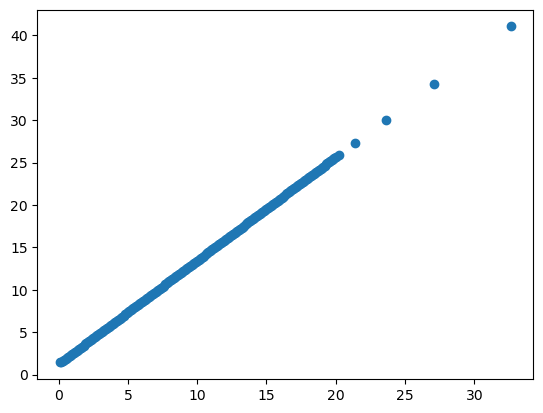

In [13]:
plt.scatter(eps[1:],np.log(1/(f[pd.NU_E][-1,1:])-1))

In [14]:
coeff = np.polyfit(eps[1:],np.log(1/(f[pd.NU_E][-1,1:])-1), 1)

In [15]:
T_cm=[]
eta=coeff[1]
T=T_cm/coeff[0]

In [16]:
print(eta)

1.2405664326586645


In [18]:
print(coeff[0])

1.2198265331765878
